In [19]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# 🔹 Cargar datos desde CSV
df = pd.read_csv("wage.csv")

# 🔹 Crear variables adicionales
df["expersq"] = df["exper"] ** 2  # Experiencia al cuadrado
df["exper_female"] = df["exper"] * df["female"]  # Interacción experiencia * mujer

# 🔹 Definir variables predictoras y objetivo
X = df[["educ", "exper", "tenure", "female", "expersq", "exper_female"]].values
y = df["lwage"].values

# 🔹 Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




# 🔹 Definir el modelo Bayesiano en NumPyro
def modelo_bayesiano(X, y=None):
    # Priors para los coeficientes
    beta = numpyro.sample("beta", dist.Normal(0, 10).expand([X.shape[1]]))
    intercepto = numpyro.sample("intercepto", dist.Normal(0, 10))
    
    # Modelo lineal
    mu = intercepto + jnp.dot(X, beta)
    
    # Verosimilitud
    sigma = numpyro.sample("sigma", dist.HalfNormal(1))
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)

# 🔹 Inferencia con NUTS en NumPyro
rng_key = random.PRNGKey(42)
nuts_kernel = NUTS(modelo_bayesiano)
mcmc = MCMC(nuts_kernel, num_samples=10000, num_warmup=2000, num_chains=1)
mcmc.run(rng_key, X_train, y_train)





sample: 100%|██████████| 12000/12000 [00:12<00:00, 973.21it/s, 255 steps of size 1.38e-02. acc. prob=0.93] 


In [20]:
# 🔹 Obtener la distribución posterior de los coeficientes
posterior_samples = mcmc.get_samples()



In [21]:
# 🔹 Extraer los coeficientes estimados y calcular media e intervalos de credibilidad (HDPI 3% - 97%)
beta_means = posterior_samples["beta"].mean(axis=0)
intercepto_mean = posterior_samples["intercepto"].mean()
beta_hdi_low = jnp.percentile(posterior_samples["beta"], 3, axis=0)
beta_hdi_high = jnp.percentile(posterior_samples["beta"], 97, axis=0)
interceptolow= jnp.percentile(posterior_samples["intercepto"], 3, axis=0)
interceptohigh= jnp.percentile(posterior_samples["intercepto"], 97, axis=0)



In [22]:
# 🔹 Crear DataFrame con los coeficientes bayesianos
coef_df_bayes = pd.DataFrame({
    "Variable": ["Intercepto"] + list(df[["educ", "exper", "tenure", "female", "expersq", "exper_female"]].columns),
    "Media": [intercepto_mean] + list(beta_means),
    "HDPI_3%":  [interceptolow.mean()]+ list(beta_hdi_low),
    "HDPI_97%": [interceptohigh.mean()] + list(beta_hdi_high)
})


In [23]:
coef_df_bayes

,Variable,Media,HDPI_3%,HDPI_97%
0,Intercepto,0.26421347,0.022177849,0.5053292
1,educ,0.08700979,0.07090077,0.10286139
2,exper,0.035631508,0.024339946,0.046961218
3,tenure,0.0146782715,0.0075801564,0.021594744
4,female,-0.17764388,-0.3085442,-0.0463679
5,expersq,-0.00059213035,-0.0008287712,-0.0003519353
6,exper_female,-0.0075147576,-0.013623498,-0.0014140947


In [24]:
# 🔹 Generar valores de experiencia para la gráfica
x_vals = np.linspace(0, df["exper"].max(), 100)

# 🔹 Calcular las curvas de cambio en el salario para mujeres y hombres con los coeficientes bayesianos
fy = intercepto_mean + beta_means[3] + beta_means[1] * x_vals + beta_means[4] * x_vals**2 + beta_means[5] * x_vals
My = intercepto_mean + beta_means[1] * x_vals + beta_means[4] * x_vals**2

# 🔹 Crear la figura con las curvas corregidas
fig = go.Figure()
fig.add_trace(go.Scatter(x=x_vals, y=fy, mode='lines', name='Mujeres', line=dict(color="red")))
fig.add_trace(go.Scatter(x=x_vals, y=My, mode='lines', name='Hombres', line=dict(color="blue")))

# 🔹 Configurar el layout de la gráfica
fig.update_layout(
    title="Brecha Salarial por Sexo al Nacer (NumPyro)",
    xaxis_title="Experiencia",
    yaxis_title="Cambio en el Salario"
)

# 🔹 Mostrar la gráfica
fig.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed

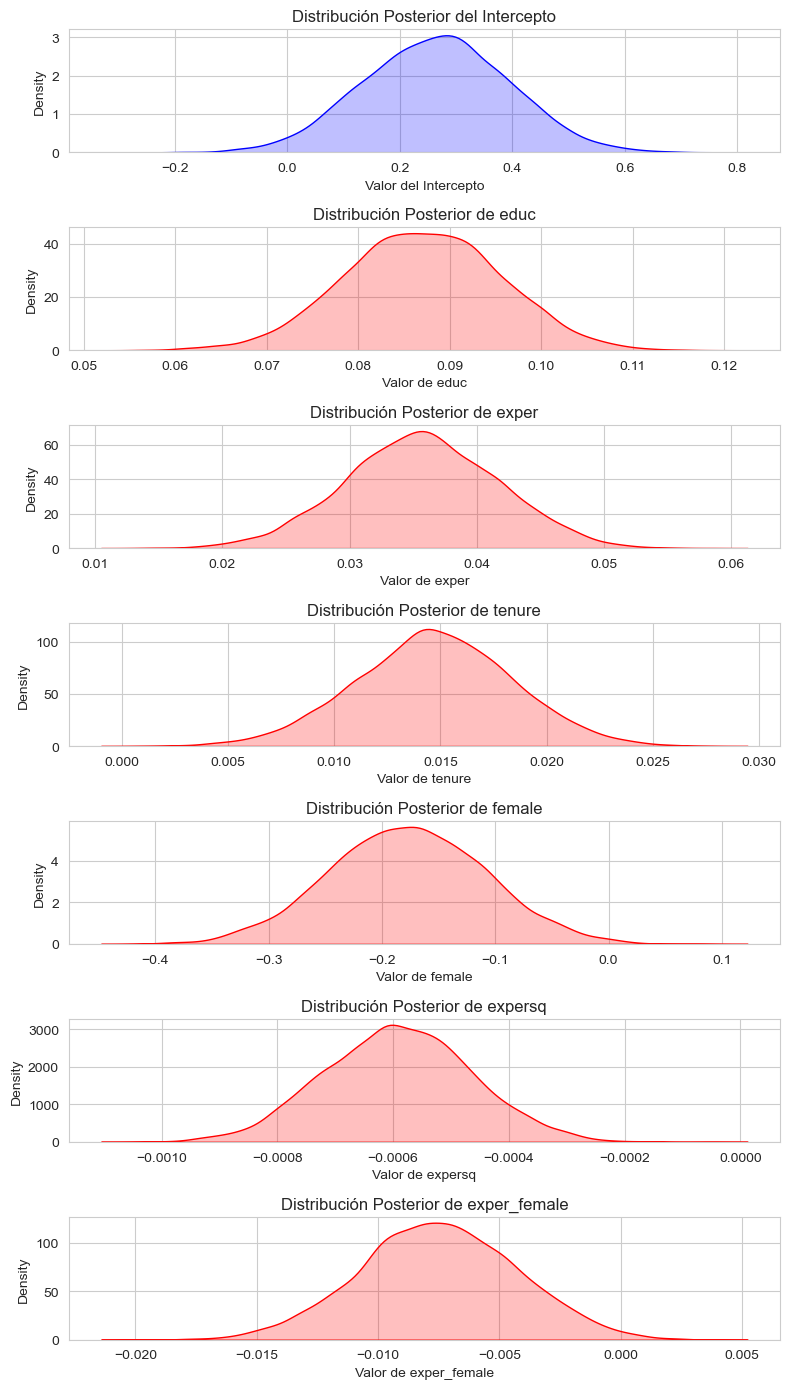

In [25]:
import seaborn as sns
# 🔹 Extraer los coeficientes estimados
beta_means = posterior_samples["beta"].mean(axis=0)
intercepto_mean = posterior_samples["intercepto"].mean()

# 🔹 Graficar las distribuciones posteriores con Matplotlib y Seaborn
sns.set_style("whitegrid")
num_vars = len(beta_means) + 1  # Incluye el intercepto
fig, axes = plt.subplots(num_vars, 1, figsize=(8, num_vars * 2))

# Graficar la distribución posterior del intercepto
sns.kdeplot(posterior_samples["intercepto"], ax=axes[0], fill=True, color="blue")
axes[0].set_title("Distribución Posterior del Intercepto")
axes[0].set_xlabel("Valor del Intercepto")

# Graficar la distribución posterior de cada coeficiente
for i, var in enumerate(df[["educ", "exper", "tenure", "female", "expersq", "exper_female"]].columns):
    sns.kdeplot(posterior_samples["beta"][:, i], ax=axes[i + 1], fill=True, color="red")
    axes[i + 1].set_title(f"Distribución Posterior de {var}")
    axes[i + 1].set_xlabel(f"Valor de {var}")

# Ajustar diseño
plt.tight_layout()
plt.show()

In [26]:
# 🔹 Extraer coeficientes estimados y predicciones en TEST
posterior_pred = posterior_samples["intercepto"][:, None] + jnp.dot(posterior_samples["beta"], X_test.T)

# 🔹 Calcular la media y el intervalo de credibilidad (HDPI 3% - 97%) para las predicciones
y_pred_mean = posterior_pred.mean(axis=0)
y_pred_hdi_low = jnp.percentile(posterior_pred, 3, axis=0)
y_pred_hdi_high = jnp.percentile(posterior_pred, 97, axis=0)

# 🔹 Crear un DataFrame con las predicciones
pred_df = pd.DataFrame({
    "Observado": y_test,
    "Predicción Media": y_pred_mean,
    "HDPI 3%": y_pred_hdi_low,
    "HDPI 97%": y_pred_hdi_high
})


In [27]:
pred_df

,Observado,Predicción Media,HDPI 3%,HDPI 97%
0,1.202972,1.492915,1.389987,1.594469
1,1.456287,1.511115,1.301710,1.721828
2,2.420368,2.334381,2.232404,2.434797
3,1.609438,1.569725,1.479913,1.657659
4,2.134166,1.962388,1.878549,2.044667
...,...,...,...,...
153,2.211566,1.867253,1.781625,1.950459
154,1.791759,1.390797,1.282362,1.496660
155,2.363680,1.662762,1.580193,1.745040
156,1.834180,1.696921,1.570241,1.823018


In [28]:
from sklearn.metrics import mean_squared_error, r2_score
# 🔹 Calcular métricas de evaluación
mse_test = mean_squared_error(y_test, y_pred_mean)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((y_test - y_pred_mean) / y_test)) * 100  # Mean Absolute Percentage Error (MAPE)
r2_test = r2_score(y_test, y_pred_mean)

# 🔹 Crear un DataFrame con las métricas
metrics_df = pd.DataFrame({
    "Métrica": ["MSE", "RMSE", "MAPE (%)", "R² Score"],
    "Valor": [mse_test, rmse_test, mape_test, r2_test]
})


In [29]:
metrics_df

,Métrica,Valor
0,MSE,0.153220
1,RMSE,0.391433
2,MAPE (%),20.365337
3,R² Score,0.472923


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


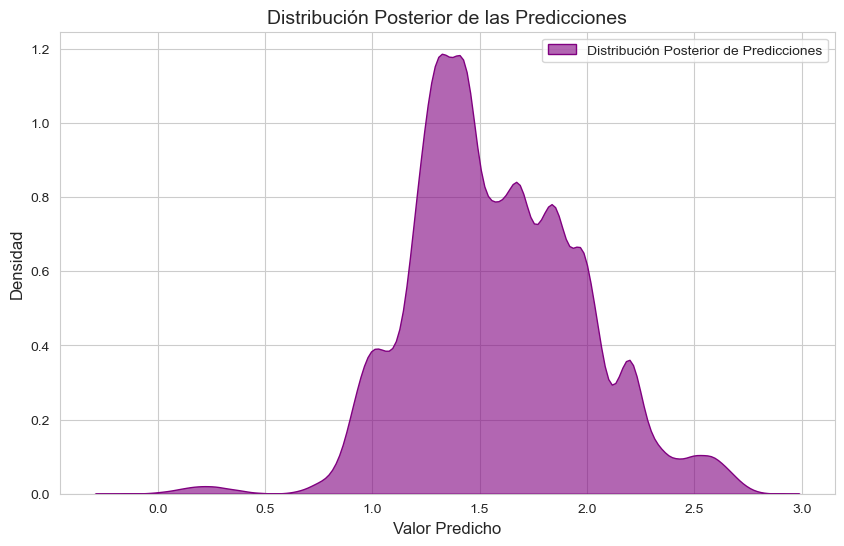

In [25]:
import seaborn as sns
# 🔹 Visualizar la distribución posterior de las predicciones
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Graficar la distribución posterior de las predicciones
sns.kdeplot(posterior_pred.flatten(), fill=True, color="purple", alpha=0.6, label="Distribución Posterior de Predicciones")

# Configurar etiquetas y título
ax.set_title("Distribución Posterior de las Predicciones", fontsize=14)
ax.set_xlabel("Valor Predicho", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)

# Agregar leyenda
ax.legend()

# Mostrar la gráfica
plt.show()

In [ ]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 Cargar datos desde CSV
df = pd.read_csv("wage.csv")

# 🔹 Crear variables adicionales
df["expersq"] = df["exper"] ** 2  # Experiencia al cuadrado
df["exper_female"] = df["exper"] * df["female"]  # Interacción experiencia * mujer

# 🔹 Definir variables predictoras y objetivo
X = df[["educ", "exper", "tenure", "female", "expersq", "exper_female"]]
y = df["lwage"]

# 🔹 Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 🔹 Agregar una columna de unos para el intercepto en el modelo
X_train_sm = sm.add_constant(X_train)  # Agregar intercepto en train
X_test_sm = sm.add_constant(X_test)    # Agregar intercepto en test

# 🔹 Ajustar el modelo de regresión lineal con Statsmodels
modelo_sm = sm.OLS(y_train, X_train_sm).fit()

# 🔹 Obtener predicciones en test
y_pred_sm = modelo_sm.predict(X_test_sm)

# 🔹 Calcular métricas de evaluación
mse_test_sm = mean_squared_error(y_test, y_pred_sm)
rmse_test_sm = np.sqrt(mse_test_sm)
mape_test_sm = np.mean(np.abs((y_test - y_pred_sm) / y_test)) * 100  # Mean Absolute Percentage Error (MAPE)
r2_test_sm = r2_score(y_test, y_pred_sm)

# 🔹 Imprimir métricas de evaluación
print("\n🔹 Métricas de Evaluación - Statsmodels")
print(f"MSE: {mse_test_sm:.4f}")
print(f"RMSE: {rmse_test_sm:.4f}")
print(f"MAPE: {mape_test_sm:.2f}%")
print(f"R² Score: {r2_test_sm:.4f}")




🔹 Métricas de Evaluación - Statsmodels
MSE: 0.1533
RMSE: 0.3915
MAPE: 20.36%
R² Score: 0.4728


In [13]:
# 🔹 Crear DataFrame con los coeficientes y sus intervalos
conf_int = modelo_sm.conf_int(alpha=0.05)  # Alpha=0.05 para 95% de confianza



coef_df_sm = pd.DataFrame({
    "Variable": ["Intercepto"] + list(X.columns),
    "Coeficiente": modelo_sm.params.values,
    "p-valor": modelo_sm.pvalues.values,
    "IC 2.5%": conf_int[0].values,  # Límite inferior del intervalo de confianza
    "IC 97.5%": conf_int[1].values  # Límite superior del intervalo de confianza
})

coef_df_sm


,Variable,Coeficiente,p-valor,IC 2.5%,IC 97.5%
0,Intercepto,0.265509,4.398439e-02,0.007193,0.523825
1,educ,0.086993,9.562904e-22,0.070273,0.103712
2,exper,0.035505,8.743464e-09,0.023655,0.047355
3,tenure,0.014702,7.415507e-05,0.007490,0.021914
4,female,-0.179150,1.030083e-02,-0.315751,-0.042549
5,expersq,-0.000590,4.075698e-06,-0.000838,-0.000342
6,exper_female,-0.007463,2.275906e-02,-0.013880,-0.001046


In [14]:
coef_df_bayes

,Variable,Media,HDPI_3%,HDPI_97%
0,Intercepto,0.26421347,0.022177849,0.5053292
1,educ,0.08700979,0.07090077,0.10286139
2,exper,0.035631508,0.024339946,0.046961218
3,tenure,0.0146782715,0.0075801564,0.021594744
4,female,-0.17764388,-0.3085442,-0.0463679
5,expersq,-0.00059213035,-0.0008287712,-0.0003519353
6,exper_female,-0.0075147576,-0.013623498,-0.0014140947


In [31]:
metrics_df

,Métrica,Valor
0,MSE,0.153220
1,RMSE,0.391433
2,MAPE (%),20.365337
3,R² Score,0.472923
